In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, target_function
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_predictions, get_improvement
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colormaps
cmap = colormaps["viridis"]
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [3]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 10,
    "g": small_saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 250,
    "monitor_convergence": False,
}

In [4]:
rank_all = [10, 50, 100]
sigma_all = [0, 0, 0]
c_all = [0, 0, 0]

for i in range(3):
    rank = rank_all[i]
    print(rank)
    case["rank"] = rank
    case["n_train"] = rank

    # parameters = optimize_hyperparameters(case)
    # sigma_all[i], c_all[i] = parameters[0], parameters[1]
sigma_all = [0.03461111, 0.01988272, 0.00627778]
c_all = [4.75308642, 9.93827160, 0.55555556]
print(sigma_all)
print(c_all)

10
50
100
[0.03461111, 0.01988272, 0.00627778]
[4.75308642, 9.9382716, 0.55555556]


In [31]:
n_sigmaDs = 251
esROMs = np.empty((case["n_test"], n_sigmaDs, 4))  # i, m, n, case

for case_nr, _rank, _sigma, _c in zip((0, 1, 2), rank_all, sigma_all, c_all):
    print("generate snapshots")
    print("build ROM and predict")
    n_train = _rank
    case["n_train"] = _rank
    case["rank"] = _rank
    case["sigma"] = _sigma
    case["c"] = _c
    shape = case["shape"]

    mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
    mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=case["n_test"], **case)
    
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    
    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, _ = get_predictions(my_sROM, mu_test, **case)

    print("we fixed sigmaS to some value (it was optimized) and see how the error behaves for each snapshot")
    #deconvolved = np.ones((*data.shape, num_iter))
    sigmaDs = np.linspace(0, 5 * (0.2/_rank), n_sigmaDs)
    for n, sigmaD in enumerate(sigmaDs):
        print(n, sigmaD, end=",\t")
        for i in range(len(mu_test)):
            deconvolved = richardson_lucy(
                x,
                X_test_sROM[i].reshape(shape),
                sigmaD,
                case["num_iter"],
            )

            esROMs[i, n, case_nr] = L2_error_rw(deconvolved, X_test[i, :], axis=0)

np.save("./esROMs.npy", esROMs)

generate snapshots
build ROM and predict
we fixed sigmaS to some value (it was optimized) and see how the error behaves for each snapshot
0 0.0,	1 0.0004,	2 0.0008,	3 0.0012000000000000001,	4 0.0016,	5 0.002,	6 0.0024000000000000002,	7 0.0028,	8 0.0032,	9 0.0036000000000000003,	10 0.004,	11 0.0044,	12 0.0048000000000000004,	13 0.005200000000000001,	14 0.0056,	15 0.006,	16 0.0064,	17 0.0068000000000000005,	18 0.007200000000000001,	19 0.0076,	20 0.008,	21 0.008400000000000001,	22 0.0088,	23 0.0092,	24 0.009600000000000001,	25 0.01,	26 0.010400000000000001,	27 0.0108,	28 0.0112,	29 0.011600000000000001,	30 0.012,	31 0.012400000000000001,	32 0.0128,	33 0.0132,	34 0.013600000000000001,	35 0.014,	36 0.014400000000000001,	37 0.0148,	38 0.0152,	39 0.015600000000000001,	40 0.016,	41 0.0164,	42 0.016800000000000002,	43 0.0172,	44 0.0176,	45 0.018000000000000002,	46 0.0184,	47 0.0188,	48 0.019200000000000002,	49 0.0196,	50 0.02,	51 0.0204,	52 0.020800000000000003,	53 0.0212,	54 0.0216,	55 0.02200

In [41]:
from scipy.spatial import distance

def relative_distance_nearest_neighbour(single_point, points):
    distances = distance.cdist(points, single_point, "euclidean").flatten()
    distances.sort()
    dim = points.shape[1]
    n = 2**dim  # 1D: 2NN; 2D: 4NN, 3D:8NN
    return distances[0] / (np.sum(distances[:n]) / dim)

def get_sigma(sigma, mu, mu_train, c):
    d = relative_distance_nearest_neighbour(mu, mu_train)
    print(mu, d)
    return sigma * (1 + c * d)


rank, sigma 10 0.03461111 0.02 0.06000000000000001
build ROM and predict
[[0.1]] 0.0
[[0.11]] 0.09999999999999995
[[0.12]] 0.20000000000000004
[[0.13]] 0.3
[[0.14]] 0.4000000000000001
[[0.15]] 0.4999999999999999
[[0.16]] 0.4000000000000001
[[0.17]] 0.3
[[0.18]] 0.20000000000000018
[[0.19]] 0.10000000000000009


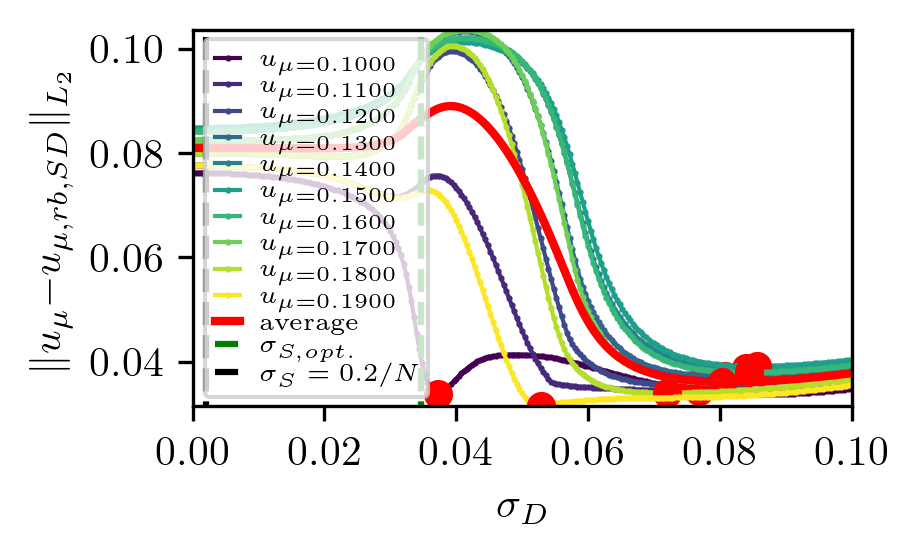

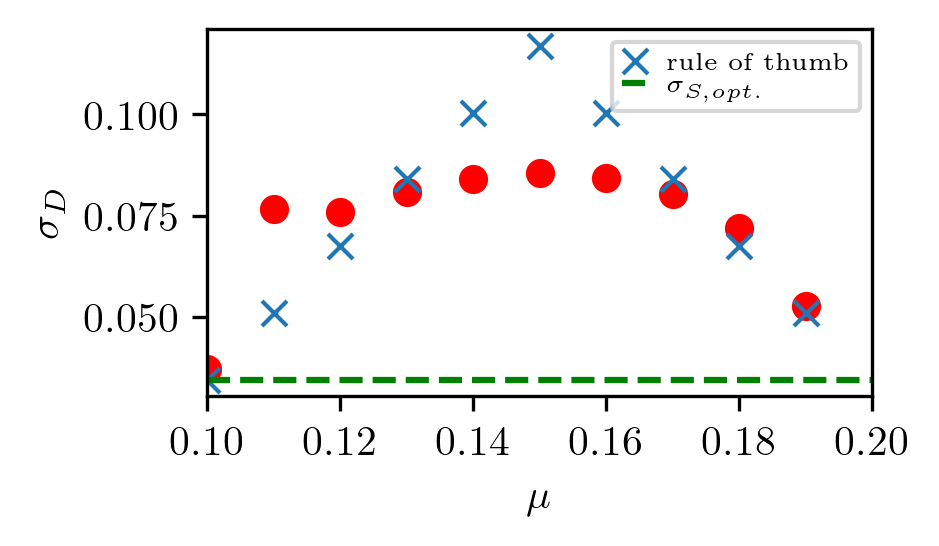

rank, sigma 50 0.01988272 0.004 0.012000000000000002
build ROM and predict
[[0.02]] 0.0
[[0.022]] 0.09999999999999991
[[0.024]] 0.2
[[0.026]] 0.3000000000000001
[[0.028]] 0.4
[[0.03]] 0.4999999999999999
[[0.032]] 0.4
[[0.034]] 0.29999999999999993
[[0.036]] 0.19999999999999982
[[0.038]] 0.09999999999999974


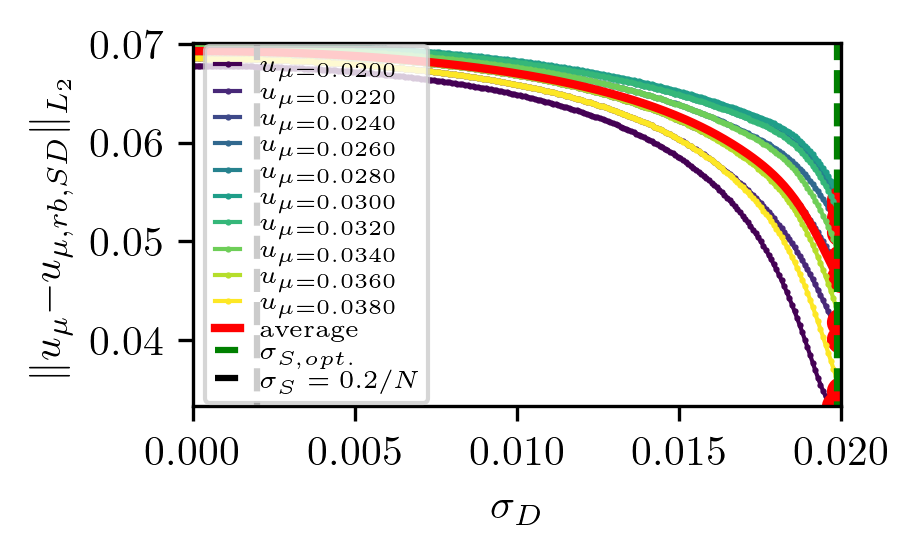

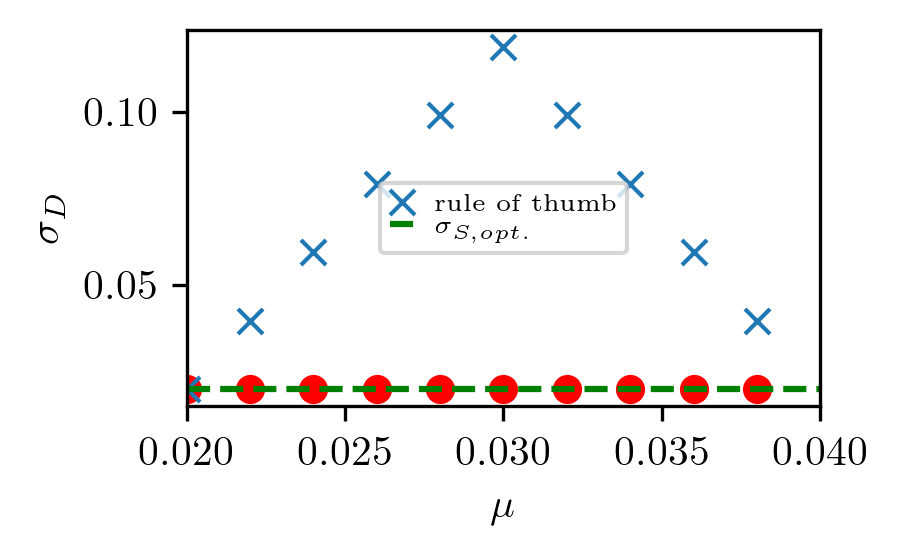

rank, sigma 100 0.00627778 0.002 0.006000000000000001
build ROM and predict
[[0.01]] 0.0
[[0.011]] 0.09999999999999991
[[0.012]] 0.2
[[0.013]] 0.3000000000000001
[[0.014]] 0.4
[[0.015]] 0.4999999999999999
[[0.016]] 0.4
[[0.017]] 0.29999999999999993
[[0.018]] 0.19999999999999982
[[0.019]] 0.09999999999999974


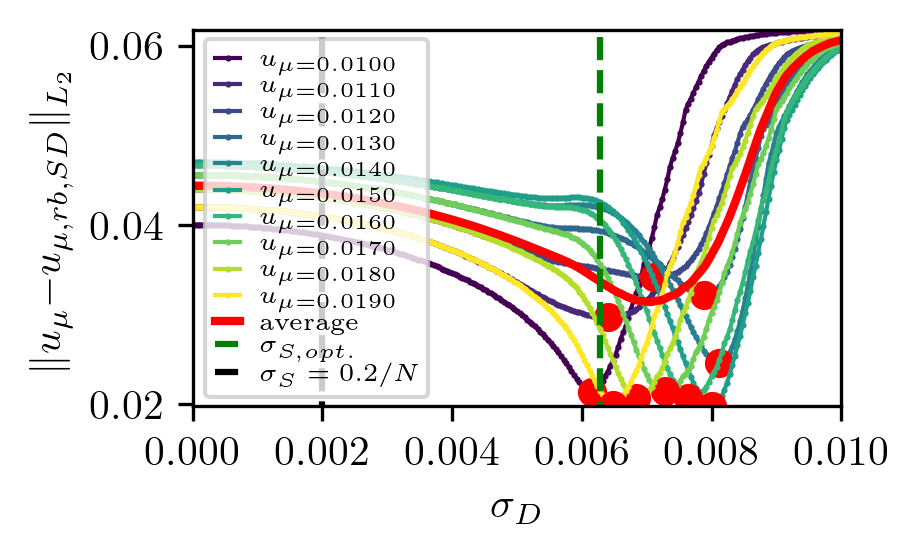

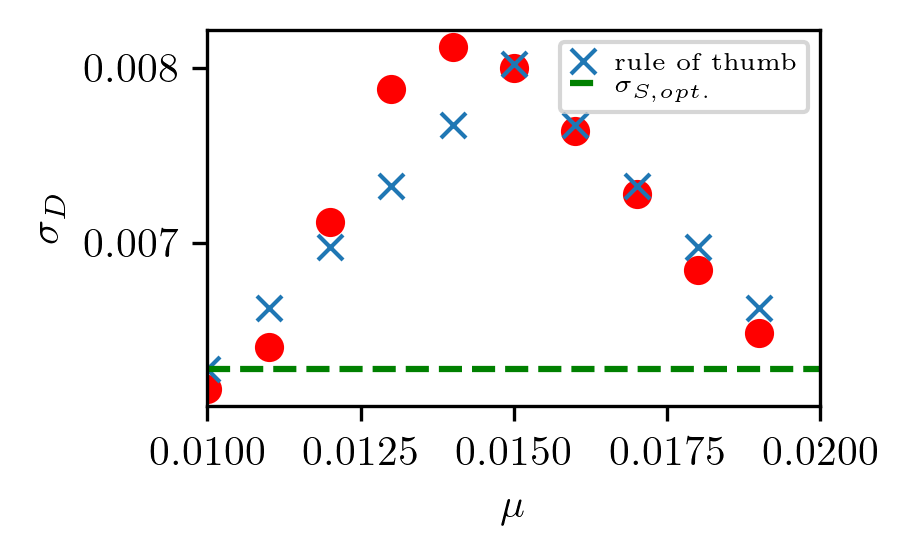

In [49]:
esROMs = np.load("./esROMs.npy")

for case_nr, _rank, _sigma, _c in zip((0, 1, 2, 3), rank_all, sigma_all, c_all):
    n_train = _rank
    case["n_train"] = _rank
    case["rank"] = _rank
    case["sigma"] = _sigma
    case["c"] = _c
    shape = case["shape"]
    print("rank, sigma", _rank, _sigma, 0.2/_rank, 3*0.2/_rank)
    print("build ROM and predict")

    mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
    mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=case["n_test"], **case)
    
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    
    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, _ = get_predictions(my_sROM, mu_test, **case)


    sigmaDs = np.linspace(0, 5* (0.2/_rank), n_sigmaDs)
    sD_opt = np.zeros_like(mu_test)
    rot = np.zeros_like(mu_test) # get_sigma(_sigma, mu_test, mu_train, _c)


    fig, ax = plt.subplots()
    for i in range(0, case["n_test"], 1):
        plt.plot(sigmaDs, esROMs[i, :, case_nr], marker=".", ms=1, lw=1,
                 color=cmap(i/(case["n_test"]-1)), label=r"$u_{\mu="+"{:.4f}".format(mu_test[i, 0])+"}$")
        i_min_error = np.argmin(esROMs[i, :, case_nr])
        rot[i] = get_sigma(_sigma, mu_test[i][None, ...], mu_train, _c)
        sD_opt[i] = sigmaDs[i_min_error]
        plt.plot(sigmaDs[i_min_error], esROMs[i, i_min_error, case_nr], "ro")
    plt.plot(sigmaDs, np.mean(esROMs[:, :, case_nr], axis=0), "r-", lw=2, label=r"average")
    plt.plot((_sigma, _sigma), (0, 1), "g--", label=r"$\sigma_{S,opt.}$")
    plt.plot((0.2/rank, 0.2/rank), (0, 1), "k--", label=r"$\sigma_S=0.2/N$")
    plt.legend(loc='center left')
    plt.xlim(0, np.max(sigmaDs))
    plt.ylim(np.min(esROMs[:, :, case_nr]), np.max(esROMs[:, :, case_nr]))
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb, SD}}\|_{L_2}$")
    plt.xlabel(r"$\sigma_D$")
    plt.show()


    # smin, smax = _sigma, _sigma
    # for i in range(0, case["n_test"], 1):
    #     i_min_error = np.argmin(esROMs[i, :, case_nr])
    #     if sigmaDs[i_min_error] < smin:
    #         smin = sigmaDs[i_min_error]
    #     if sigmaDs[i_min_error] > smax:
    #         smax = sigmaDs[i_min_error]
    # srange = smax-smin
    # smin, smax = smin-srange*.5, smax+srange*.5
    # mask = (smin<sigmaDs) & (sigmaDs< smax)
    # ymin, ymax = np.min(esROMs[:, mask, case_nr]), np.max(esROMs[:, mask, case_nr])

    
    # fig, ax = plt.subplots(figsize=(plot_width_in*2, plot_width_in*2/1.61803398875))
    # for i in range(0, case["n_test"], 1):
    #     plt.plot(sigmaDs, esROMs[i, :, case_nr], marker=".", ms=1, lw=1,
    #              color=cmap(i/case["n_test"]), label=r"$u_{\mu="+"{:.4f}".format(mu_test[i, 0])+"}$")
    #     i_min_error = np.argmin(esROMs[i, :, case_nr])
    #     
    #     plt.plot(sigmaDs[i_min_error], esROMs[i, i_min_error, case_nr], "ro")
    # #plt.plot(sigmaDs, np.mean(esROMs[:, -1, :, case_nr], axis=0), "k--")
    # plt.plot((_sigma, _sigma), (ymin, ymax), "k--")
    # plt.legend()
    # plt.xlim(smin, smax)
    # plt.ylim(ymin, ymax)
    # plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb, SD_{n_10}}}\|_{L_2}$")
    # plt.xlabel(r"$\sigma$")
    # plt.show()


    fig, ax = plt.subplots()
    plt.plot(mu_test[:, 0], sD_opt[:, 0], "ro")
    plt.plot(mu_test[:, 0], rot[:, 0], "C0x", label=r"rule of thumb")
    plt.plot((mu_train[1,0], mu_train[2,0]), (_sigma, _sigma), "g--", label=r"$\sigma_{S,opt.}$")
    #plt.plot((mu_train[1,0], mu_train[2,0]), (0.2/rank, 0.2/rank), "k--", label=r"$\sigma_S=0.2/N$")
    
    plt.xlim(mu_train[1,0], mu_train[2,0])
    plt.xlabel(r"$\mu$")
    plt.ylabel(r"$\sigma_D$")
    plt.legend()
    plt.show()